# Interactive Model Predictions

Explore how the Bayesian causal inference model predicts audio-visual duration estimation behaviour.

**What this notebook shows:**
- How the predicted PSE (point of subjective equality) shifts with audio-visual conflict
- How the psychometric function changes across conflict levels
- How changing model parameters (sensory noise, prior on common cause) affects predictions
- Comparison of Causal Inference vs Fusion vs Selection models

**No fitting required** — predictions are computed analytically from the model equations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import glob
import os
from scipy.stats import norm
from scipy.optimize import brentq
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Try to load plot style
try:
    import plot_style
except ImportError:
    plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries loaded.')

Libraries loaded.


## 1. Model Definitions

The experiment uses a 2AFC paradigm: on each trial a **standard** (audio + visual, with possible conflict) is compared to an **audio-only test**.

All models work in log-duration space. The key parameters are:
- **σa** — auditory noise (standard deviation in log space, two levels: low SNR / high SNR)
- **σv** — visual noise (standard deviation in log space)
- **pc** — prior probability that audio and visual come from a common source
- **λ** — lapse rate

The visual reliability weight under fusion is: **w_v = σa² / (σa² + σv²)**

In [2]:
# ── Analytical model predictions ──────────────────────────────────────────────

def predict_psychometric_ci(delta, sigma_a, sigma_v, p_c, lapse, conflict, standard_dur=0.5):
    """
    Causal inference (lognorm) model psychometric function.

    Parameters
    ----------
    delta        : log(test_dur / standard_dur)  [array]
    sigma_a      : auditory noise in log space
    sigma_v      : visual noise in log space
    p_c          : prior P(common cause)
    lapse        : lapse rate
    conflict     : visual - auditory conflict in seconds
    standard_dur : standard duration in seconds

    Returns
    -------
    P(chose test longer)  [same shape as delta]
    """
    delta = np.asarray(delta)

    # Log-space conflict (visual standard is shifted by conflict)
    log_c = np.log(1.0 + conflict / standard_dur) if conflict > -standard_dur else 0.0

    # Visual reliability weight
    w_v = sigma_a**2 / (sigma_a**2 + sigma_v**2)

    # PSE shift from visual pull (under common cause)
    pse_c = w_v * log_c

    # Decision noise
    sigma_fused = np.sqrt(2.0 * sigma_a**2 * sigma_v**2 / (sigma_a**2 + sigma_v**2))
    sigma_ind   = np.sqrt(2.0) * sigma_a

    p_common = p_c       * norm.cdf((delta - pse_c) / sigma_fused)
    p_indep  = (1 - p_c) * norm.cdf(delta / sigma_ind)

    return (1 - lapse) * (p_common + p_indep) + lapse / 2.0


def predict_psychometric_fusion(delta, sigma_a, sigma_v, lapse, conflict, standard_dur=0.5):
    """Forced fusion model (p_c = 1 always)."""
    return predict_psychometric_ci(delta, sigma_a, sigma_v, 1.0, lapse, conflict, standard_dur)


def predict_psychometric_selection(delta, sigma_a, lapse, **kwargs):
    """Sensory selection model — ignores visual, uses auditory only."""
    delta = np.asarray(delta)
    sigma_ind = np.sqrt(2.0) * sigma_a
    return (1 - lapse) * norm.cdf(delta / sigma_ind) + lapse / 2.0


def compute_pse(predict_fn, conflict, *args, **kwargs):
    """Find PSE (delta where P = 0.5) by bisection."""
    try:
        return brentq(
            lambda d: predict_fn(d, *args, conflict=conflict, **kwargs) - 0.5,
            -1.5, 1.5, xtol=1e-6
        )
    except ValueError:
        return np.nan


# Conflict levels used in the experiment (seconds)
CONFLICTS = np.array([-0.25, -0.167, -0.083, 0.0, 0.083, 0.167, 0.25])
CONFLICTS_MS = CONFLICTS * 1000  # for plotting
STANDARD_DUR = 0.5

print('Model functions defined.')

Model functions defined.


## 2. Load Fitted Parameters

Pre-fitted parameters from `model_fits/` are loaded here for reference. The interactive sliders below start at the group-average fitted values.

In [3]:
def load_fitted_params(model_type='lognorm_LapseFix_sharedPrior'):
    """Load fitted parameters for all participants, return mean ± std."""
    params_all = []
    for path in sorted(glob.glob(f'model_fits/P*/*_{model_type}_fit.json')):
        with open(path) as f:
            d = json.load(f)
        params_all.append(d['fittedParams'])
    if not params_all:
        print(f'No fits found for {model_type}')
        return None, None
    params_all = np.array(params_all)
    return np.nanmean(params_all, axis=0), np.nanstd(params_all, axis=0)

# Load group-average lognorm (CI) parameters
# Params: [lambda, sigma_a1 (low noise), sigma_v, p_c, sigma_a2 (high noise)]
mean_params, std_params = load_fitted_params('lognorm_LapseFix_sharedPrior')

if mean_params is not None:
    lam, sa1, sv, pc, sa2 = mean_params
    print(f'Group-average lognorm parameters:')
    print(f'  λ (lapse)     = {lam:.3f} ± {std_params[0]:.3f}')
    print(f'  σa low noise  = {sa1:.3f} ± {std_params[1]:.3f}')
    print(f'  σv            = {sv:.3f}  ± {std_params[2]:.3f}')
    print(f'  pc            = {pc:.3f}  ± {std_params[3]:.3f}')
    print(f'  σa high noise = {sa2:.3f} ± {std_params[4]:.3f}')
else:
    # Fallback defaults if model_fits not found
    lam, sa1, sv, pc, sa2 = 0.05, 0.25, 0.55, 0.75, 0.60
    print('Using default parameters (model_fits not found).')

Group-average lognorm parameters:
  λ (lapse)     = 0.094 ± 0.066
  σa low noise  = 0.280 ± 0.109
  σv            = 0.566  ± 0.391
  pc            = 0.742  ± 0.309
  σa high noise = 0.824 ± 0.382


## 3. Interactive: PSE vs Conflict

Use the sliders to explore how model parameters affect the predicted PSE shift as a function of audio-visual conflict.

**Key intuitions:**
- **Higher pc** → stronger visual pull (larger PSE shifts)
- **Higher σv** (noisier vision) → less visual weight → smaller shifts
- **Higher σa** (noisier audition) → more visual weight → larger shifts
- **Fusion** (pc=1) gives maximum shifts; **Selection** gives zero shifts

In [4]:
def plot_pse_vs_conflict(sigma_a_low, sigma_a_high, sigma_v, p_c, lapse, show_fusion, show_selection):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {'low': '#2196F3', 'high': '#FF5722'}
    labels = {'low': 'Low auditory noise (σa={:.2f})'.format(sigma_a_low),
              'high': 'High auditory noise (σa={:.2f})'.format(sigma_a_high)}

    for noise_label, sigma_a in [('low', sigma_a_low), ('high', sigma_a_high)]:
        pse_ci  = [compute_pse(predict_psychometric_ci,     c, sigma_a, sigma_v, p_c, lapse) for c in CONFLICTS]
        pse_ms  = np.array(pse_ci) * STANDARD_DUR * 1000  # convert log-ratio to ms

        ax.plot(CONFLICTS_MS, pse_ms, 'o-', color=colors[noise_label],
                label=f'CI — {labels[noise_label]}', lw=2, ms=6)

        if show_fusion:
            pse_f = [compute_pse(predict_psychometric_fusion, c, sigma_a, sigma_v, lapse) for c in CONFLICTS]
            pse_f_ms = np.array(pse_f) * STANDARD_DUR * 1000
            ax.plot(CONFLICTS_MS, pse_f_ms, '--', color=colors[noise_label],
                    label=f'Fusion — {noise_label} noise', lw=1.5, alpha=0.6)

        if show_selection:
            pse_s = [compute_pse(predict_psychometric_selection, c, sigma_a, lapse) for c in CONFLICTS]
            pse_s_ms = np.array(pse_s) * STANDARD_DUR * 1000
            ax.plot(CONFLICTS_MS, pse_s_ms, ':', color=colors[noise_label],
                    label=f'Selection — {noise_label} noise', lw=1.5, alpha=0.6)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel('Conflict (ms)', fontsize=13)
    ax.set_ylabel('PSE shift (ms)', fontsize=13)
    ax.set_title('Predicted PSE vs Conflict', fontsize=14)
    ax.legend(fontsize=9, loc='upper left')

    # Annotate visual weight
    for noise_label, sigma_a in [('low', sigma_a_low), ('high', sigma_a_high)]:
        w_v = sigma_a**2 / (sigma_a**2 + sigma_v**2)
        ax.text(0.98, 0.05 if noise_label == 'low' else 0.12,
                f'w_v ({noise_label}) = {w_v:.2f}',
                transform=ax.transAxes, ha='right', fontsize=9,
                color=colors[noise_label])

    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_pse_vs_conflict,
    sigma_a_low   = widgets.FloatSlider(value=round(float(sa1),2), min=0.05, max=1.5, step=0.05, description='σa low',  continuous_update=False),
    sigma_a_high  = widgets.FloatSlider(value=round(float(sa2),2), min=0.05, max=1.5, step=0.05, description='σa high', continuous_update=False),
    sigma_v       = widgets.FloatSlider(value=round(float(sv),2),  min=0.05, max=1.5, step=0.05, description='σv',       continuous_update=False),
    p_c           = widgets.FloatSlider(value=round(float(pc),2),  min=0.0,  max=1.0, step=0.05, description='pc',       continuous_update=False),
    lapse         = widgets.FloatSlider(value=round(float(lam),3), min=0.0,  max=0.2, step=0.01, description='λ (lapse)',continuous_update=False),
    show_fusion   = widgets.Checkbox(value=True,  description='Show Fusion'),
    show_selection= widgets.Checkbox(value=True,  description='Show Selection'),
);

interactive(children=(FloatSlider(value=0.28, continuous_update=False, description='σa low', max=1.5, min=0.05…

## 4. Interactive: Psychometric Functions

Shows the full psychometric curve (P(chose test) vs log duration ratio) at each conflict level for a chosen noise condition.

In [ ]:
def plot_psychometric_curves(sigma_a, sigma_v, p_c, lapse, noise_label):
    delta_range = np.linspace(-1.5, 1.5, 300)

    cmap = plt.cm.RdBu
    conflicts_to_show = [-0.25, -0.167, -0.083, 0.0, 0.083, 0.167, 0.25]
    colors = [cmap(i / (len(conflicts_to_show) - 1)) for i in range(len(conflicts_to_show))]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, model_label, predict_fn in [
        (axes[0], f'Causal Inference (pc={p_c:.2f})',
         lambda d, c: predict_psychometric_ci(d, sigma_a, sigma_v, p_c, lapse, c)),
        (axes[1], 'Fusion (pc=1)',
         lambda d, c: predict_psychometric_fusion(d, sigma_a, sigma_v, lapse, c)),
    ]:
        for c, col in zip(conflicts_to_show, colors):
            p = predict_fn(delta_range, c)
            ax.plot(delta_range * 1000, p, color=col, lw=2,
                    label=f'{c*1000:.0f} ms')

        ax.axhline(0.5, color='gray', lw=0.8, ls='--')
        ax.axvline(0.0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel('Log duration ratio × 1000 (≈ Δms / 500ms)', fontsize=11)
        ax.set_ylabel('P(chose test)', fontsize=11)
        ax.set_title(f'{model_label}\n{noise_label} noise (σa={sigma_a:.2f}, σv={sigma_v:.2f})', fontsize=11)
        ax.set_ylim(0, 1)

    # Shared colorbar legend
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(-250, 250))
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label='Conflict (ms)', fraction=0.02, pad=0.02)

    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_psychometric_curves,
    sigma_a    = widgets.FloatSlider(value=round(float(sa1),2), min=0.05, max=1.5, step=0.05, description='σa',       continuous_update=False),
    sigma_v    = widgets.FloatSlider(value=round(float(sv),2),  min=0.05, max=1.5, step=0.05, description='σv',       continuous_update=False),
    p_c        = widgets.FloatSlider(value=round(float(pc),2),  min=0.0,  max=1.0, step=0.05, description='pc',       continuous_update=False),
    lapse      = widgets.FloatSlider(value=round(float(lam),3), min=0.0,  max=0.2, step=0.01, description='λ (lapse)',continuous_update=False),
    noise_label= widgets.ToggleButtons(options=['Low', 'High'], description='Noise level'),
);

interactive(children=(FloatSlider(value=0.28, continuous_update=False, description='σa', max=1.5, min=0.05, st…

## 5. Model Comparison — Fitted Parameters vs Data

Compare the three models (CI, Fusion, Selection) using the group-average fitted parameters from `model_fits/`, overlaid on the group-average data.

In [6]:
# Load group data and compute empirical PSE per participant x conflict x noise
def compute_empirical_pse(df, conflict_bins=None):
    """Bin by conflict level and compute PSE from proportion chose-test."""
    if conflict_bins is None:
        conflict_bins = np.array([-0.27, -0.21, -0.14, -0.04, 0.04, 0.14, 0.21, 0.27])
    df = df.copy()
    df = df.dropna(subset=['conflictDur', 'audNoise', 'chose_test', 'deltaDurS', 'standardDur'])
    df = df[df['audNoise'].isin([0.1, 1.2])]

    # Bin conflicts
    df['conflict_bin'] = pd.cut(df['conflictDur'], bins=conflict_bins,
                                 labels=np.round((conflict_bins[:-1] + conflict_bins[1:]) / 2, 3))
    df['conflict_bin'] = df['conflict_bin'].astype(float)

    results = []
    for pid in df['participantID'].unique():
        for noise in [0.1, 1.2]:
            for cb in df['conflict_bin'].dropna().unique():
                sub = df[(df['participantID'] == pid) &
                         (df['audNoise'] == noise) &
                         (df['conflict_bin'] == cb)]
                if len(sub) < 10:
                    continue
                # Simple PSE estimate: delta at which proportion = 0.5 (linear interpolation)
                grouped = sub.groupby('deltaDurS')['chose_test'].mean().reset_index().sort_values('deltaDurS')
                if grouped['chose_test'].max() < 0.5 or grouped['chose_test'].min() > 0.5:
                    continue
                try:
                    pse = np.interp(0.5, grouped['chose_test'].values, grouped['deltaDurS'].values)
                    results.append({'participantID': pid, 'audNoise': noise,
                                    'conflict_bin': cb, 'pse': pse})
                except Exception:
                    pass
    return pd.DataFrame(results)


try:
    df_main = pd.read_csv('data/all_main.csv')
    if 'chose_test' not in df_main.columns:
        df_main['chose_test'] = (df_main['responses'] == df_main['order']).astype(int)
    pse_df = compute_empirical_pse(df_main)
    data_loaded = True
    print(f'Data loaded: {len(df_main)} trials, {df_main["participantID"].nunique()} participants')
except Exception as e:
    data_loaded = False
    print(f'Could not load data: {e}')

Data loaded: 28532 trials, 12 participants


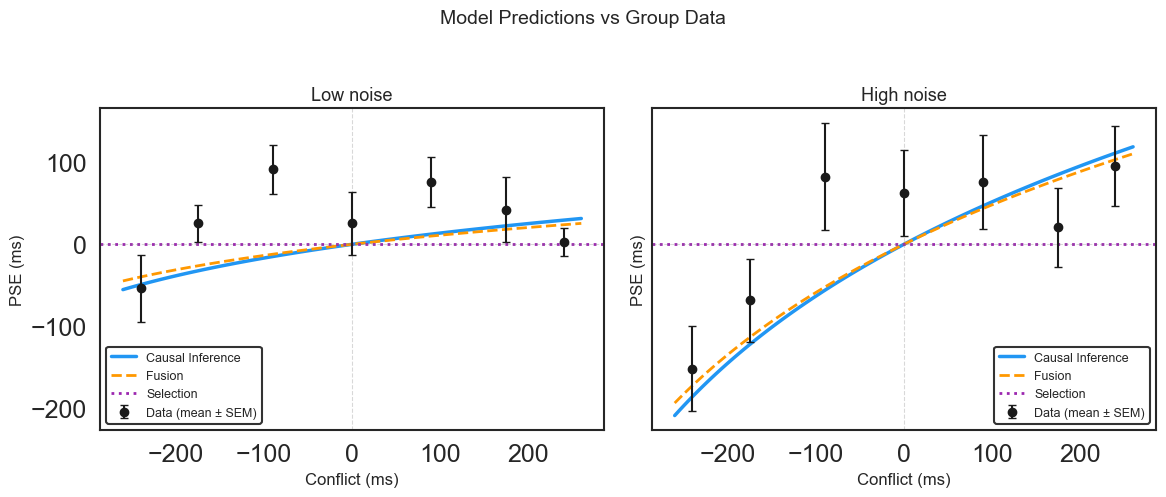

Saved to model_predictions_comparison.pdf


In [7]:
# Load group-average fitted parameters for all three models
def get_group_params(model_type):
    mean_p, _ = load_fitted_params(model_type)
    return mean_p

ci_params     = get_group_params('lognorm_LapseFix_sharedPrior')
fusion_params = get_group_params('fusionOnlyLogNorm_LapseFix_sharedPrior')

# Predict PSE curves
conflict_fine = np.linspace(-0.26, 0.26, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
noise_levels = [(0.1, 'Low noise'), (1.2, 'High noise')]

for ax, (noise_val, noise_label) in zip(axes, noise_levels):

    # Choose sigma_a based on noise level
    ci_sa = ci_params[1] if noise_val == 0.1 else ci_params[4]         # σa1 or σa2
    fu_sa = fusion_params[1] if noise_val == 0.1 else fusion_params[3]  # fusion has 4 params

    # CI model
    pse_ci = np.array([compute_pse(predict_psychometric_ci, c,
                                    ci_sa, ci_params[2], ci_params[3], ci_params[0])
                        for c in conflict_fine]) * STANDARD_DUR * 1000
    ax.plot(conflict_fine * 1000, pse_ci, '-', color='#2196F3', lw=2.5, label='Causal Inference')

    # Fusion model
    pse_fu = np.array([compute_pse(predict_psychometric_fusion, c,
                                    fu_sa, fusion_params[2], fusion_params[0])
                        for c in conflict_fine]) * STANDARD_DUR * 1000
    ax.plot(conflict_fine * 1000, pse_fu, '--', color='#FF9800', lw=2, label='Fusion')

    # Selection (PSE = 0 regardless of conflict)
    ax.axhline(0, ls=':', color='#9C27B0', lw=2, label='Selection')

    # Data
    if data_loaded:
        sub = pse_df[pse_df['audNoise'] == noise_val]
        grp = sub.groupby('conflict_bin')['pse'].agg(['mean', 'sem']).reset_index()
        grp['pse_ms'] = grp['mean'] * 1000
        grp['sem_ms'] = grp['sem']  * 1000
        ax.errorbar(grp['conflict_bin'] * 1000, grp['pse_ms'], yerr=grp['sem_ms'],
                    fmt='ko', ms=6, capsize=3, lw=1.5, zorder=5, label='Data (mean ± SEM)')

    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.3)
    ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.3)
    ax.set_xlabel('Conflict (ms)', fontsize=12)
    ax.set_ylabel('PSE (ms)', fontsize=12)
    ax.set_title(noise_label, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle('Model Predictions vs Group Data', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('model_predictions_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved to model_predictions_comparison.pdf')

## 6. Explore Individual Participants

Load and display fitted parameters for each participant alongside their predicted PSE curves.

In [8]:
def plot_participant(participant_id, model_type='lognorm_LapseFix_sharedPrior'):
    path = f'model_fits/{participant_id}/{participant_id}_{model_type}_fit.json'
    if not os.path.exists(path):
        print(f'No fit found at {path}')
        return

    with open(path) as f:
        fit = json.load(f)

    params = fit['fittedParams']
    lam, sa1, sv, pc, sa2 = params[:5]

    print(f'Participant: {participant_id}   Model: {model_type}')
    print(f'  AIC={fit["AIC"]:.1f}  BIC={fit["BIC"]:.1f}')
    print(f'  λ={lam:.3f}  σa_low={sa1:.3f}  σv={sv:.3f}  pc={pc:.3f}  σa_high={sa2:.3f}')
    w_v_low  = sa1**2 / (sa1**2 + sv**2)
    w_v_high = sa2**2 / (sa2**2 + sv**2)
    print(f'  Visual weight: {w_v_low:.2f} (low noise), {w_v_high:.2f} (high noise)')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, (noise_label, sigma_a) in zip(axes, [('Low noise', sa1), ('High noise', sa2)]):
        pse_ci = np.array([compute_pse(predict_psychometric_ci, c, sigma_a, sv, pc, lam)
                            for c in conflict_fine]) * STANDARD_DUR * 1000
        ax.plot(conflict_fine * 1000, pse_ci, '-', color='#2196F3', lw=2.5, label='CI fit')
        ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.4)
        ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.4)

        # Overlay data if available
        if data_loaded:
            noise_val = 0.1 if 'Low' in noise_label else 1.2
            sub = pse_df[(pse_df['participantID'] == participant_id) &
                          (pse_df['audNoise'] == noise_val)]
            if len(sub) > 0:
                ax.scatter(sub['conflict_bin'] * 1000, sub['pse'] * 1000,
                           color='black', s=40, zorder=5, label='Data')

        ax.set_title(f'{noise_label} (σa={sigma_a:.2f})', fontsize=12)
        ax.set_xlabel('Conflict (ms)', fontsize=11)
        ax.set_ylabel('PSE (ms)', fontsize=11)
        ax.legend(fontsize=9)

    plt.suptitle(f'{participant_id} — {model_type}', fontsize=13)
    plt.tight_layout()
    plt.show()


participant_ids = sorted([os.path.basename(p) for p in glob.glob('model_fits/P*') if os.path.isdir(p)])

widgets.interact(
    plot_participant,
    participant_id = widgets.Dropdown(options=participant_ids, description='Participant'),
    model_type     = widgets.Dropdown(
        options=['lognorm_LapseFix_sharedPrior',
                 'fusionOnlyLogNorm_LapseFix_sharedPrior',
                 'switchingFree_LapseFix_sharedPrior',
                 'probabilityMatchingLogNorm_LapseFix_sharedPrior'],
        description='Model'
    ),
);

interactive(children=(Dropdown(description='Participant', options=('P01', 'P02', 'P03', 'P04', 'P06', 'P07', '…